# Case Study 2 — Report 7 (Test 5)

**Unsupervised Domain Adaptation — CORAL loss + validation split**

Student: Sanjeev Veeramani (Matr. 100004303)
Supervisor: Prof. Dr. Binh Vu

---

**⚠️ IMPORTANT — Methodology change from Test 1–4.**

**Test 1–4:** Zero-shot. Model never sees SEED during training.

**Test 5 (this notebook):** Unsupervised Domain Adaptation. Model sees SEED **feature values** during training (but never SEED labels). Matches Imtiaz & Khan 2024's setup.

**Only run this test with Prof. Vu's approval** — it changes the project's methodology from pure zero-shot to unsupervised DA.

---

**Objective.** Improve cross-dataset transfer by aligning DEAP and SEED feature covariances during training using CORAL loss. Compare to Imtiaz & Khan 2024's 67.44% (also unsupervised DA).

**Method (CORAL — CORrelation ALignment):**
1. During each training batch, compute feature covariance for DEAP batch AND SEED batch
2. Loss = classification loss + λ × ||cov(DEAP) − cov(SEED)||²_F
3. Model learns features whose second-order statistics match across datasets
4. SEED labels are NEVER used — only feature values

**Zero-shot compliance:** ❌ NO. This uses SEED features during training. Not zero-shot.

**Validation:** Same subject-based val/test split as Test 4 (val subjects 1-3, test subjects 4-15). CORAL uses SEED features from val + test but never SEED labels.

**Expected runtime:** ~2 hours on L4 GPU.

**Expected result:** 65-70% binary (comparable to Imtiaz & Khan 67.44%).

## 1. Setup

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = '/content/drive/MyDrive/case_study_2'
assert os.path.isdir(PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import torch, numpy as np, pandas as pd, time, gc
from pathlib import Path
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, precision_score, recall_score,
                             confusion_matrix)

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Device: NVIDIA L4


## 2. Configuration

In [5]:
CONFIG = {
    'deap_de_perwindow':  'processed/X_deap_DE_zscored.npy',
    'deap_subj_ids':      'processed/deap_subject_ids.npy',
    'deap_val_bin':       'processed/y_deap_valence.npy',
    'deap_val_3c':        'processed/y_deap_3class.npy',

    'seed_de_perwindow':  'processed/X_seed_DE_zscored.npy',
    'seed_subj_ids':      'processed/seed_subject_ids.npy',
    'seed_labels':        'processed/y_seed.npy',
    'seed_de_pertrial':      'processed/X_seed_DE_pertrial.npy',
    'seed_subj_ids_pertrial':'processed/subj_seed_pertrial.npy',
    'seed_labels_pertrial':  'processed/y_seed_pertrial.npy',

    'deap_n_subjects':    32,
    'deap_n_trials':      40,

    'results_dir':  'results/report7_test5_coral',

    'lr':            1e-3,
    'weight_decay':  1e-4,
    'mmd_lambda':    0.1,     # subject-MMD (same as before)
    'coral_lambda':  1.0,     # NEW: CORAL loss weight

    'val_subjects':  [1, 2, 3],
    'test_subjects': list(range(4, 16)),
}

RESULTS_DIR = Path(PROJECT_ROOT) / CONFIG['results_dir']
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Val subjects: {CONFIG["val_subjects"]}')
print(f'Test subjects: {CONFIG["test_subjects"]}')

Val subjects: [1, 2, 3]
Test subjects: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


## 3. Load DEAP + SEED + split

In [6]:
root = Path(PROJECT_ROOT)

# DEAP
X_deap_pw  = np.load(root / CONFIG['deap_de_perwindow']).astype(np.float32)
subj_deap  = np.load(root / CONFIG['deap_subj_ids']).astype(np.int64)
y_deap_bin = np.load(root / CONFIG['deap_val_bin']).astype(np.int64)
y_deap_3c  = np.load(root / CONFIG['deap_val_3c']).astype(np.int64)

n_sub_d, n_tr_d = CONFIG['deap_n_subjects'], CONFIG['deap_n_trials']
n_win_d = X_deap_pw.shape[0] // (n_sub_d * n_tr_d)
X_deap_pt = X_deap_pw.reshape(n_sub_d, n_tr_d, n_win_d, -1).mean(axis=2).reshape(-1, X_deap_pw.shape[-1])
y_deap_bin_pt = y_deap_bin.reshape(n_sub_d, n_tr_d, n_win_d)[:, :, 0].reshape(-1)
y_deap_3c_pt  = y_deap_3c.reshape(n_sub_d, n_tr_d, n_win_d)[:, :, 0].reshape(-1)
subj_deap_pt = np.repeat(np.arange(1, n_sub_d + 1), n_tr_d).astype(np.int64)

# SEED per-window + per-trial
X_seed_pw    = np.load(root / CONFIG['seed_de_perwindow']).astype(np.float32)
subj_seed_pw = np.load(root / CONFIG['seed_subj_ids']).astype(np.int64)
y_seed_pw    = np.load(root / CONFIG['seed_labels']).astype(np.int64)
X_seed_pt    = np.load(root / CONFIG['seed_de_pertrial']).astype(np.float32)
subj_seed_pt = np.load(root / CONFIG['seed_subj_ids_pertrial']).astype(np.int64)
y_seed_pt    = np.load(root / CONFIG['seed_labels_pertrial']).astype(np.int64)
print(f'DEAP per-window: {X_deap_pw.shape}, per-trial: {X_deap_pt.shape}')
print(f'SEED per-window: {X_seed_pw.shape}, per-trial: {X_seed_pt.shape}')

DEAP per-window: (152320, 160), per-trial: (1280, 160)
SEED per-window: (304785, 160), per-trial: (675, 160)


## 4. Split SEED into val/test by subject

In [7]:
val_subjs = set(CONFIG['val_subjects'])
test_subjs = set(CONFIG['test_subjects'])

def split_by_subject(X, y, subj):
    val_mask  = np.isin(subj, list(val_subjs))
    test_mask = np.isin(subj, list(test_subjs))
    return {
        'val':  (X[val_mask],  y[val_mask],  subj[val_mask]),
        'test': (X[test_mask], y[test_mask], subj[test_mask]),
    }

SEED_SPLITS = {
    'per_trial':  split_by_subject(X_seed_pt, y_seed_pt, subj_seed_pt),
    'per_window': split_by_subject(X_seed_pw, y_seed_pw, subj_seed_pw),
}
for k, v in SEED_SPLITS.items():
    print(f'{k}: val {v["val"][0].shape}, test {v["test"][0].shape}')

per_trial: val (135, 160), test (540, 160)
per_window: val (60957, 160), test (243828, 160)


## 5. Build val + test sets per mapping

In [8]:
def map_binary(X, y, subj):
    mask = (y == 0) | (y == 2)
    return X[mask], (y[mask] == 2).astype(np.int64), subj[mask]

def map_3class(X, y, subj):
    return X, y.astype(np.int64), subj

DATA = {}
for protocol in ['per_trial', 'per_window']:
    for role in ['val', 'test']:
        X, y, s = SEED_SPLITS[protocol][role]
        for mapping, fn in [('binary', map_binary), ('3class', map_3class)]:
            Xm, ym, sm = fn(X, y, s)
            DATA[(mapping, protocol, role)] = (Xm, ym, sm)
            print(f'{mapping} × {protocol} × {role}: X {Xm.shape}, counts {np.bincount(ym).tolist()}')

binary × per_trial × val: X (90, 160), counts [45, 45]
3class × per_trial × val: X (135, 160), counts [45, 45, 45]
binary × per_trial × test: X (360, 160), counts [180, 180]
3class × per_trial × test: X (540, 160), counts [180, 180, 180]
binary × per_window × val: X (41130, 160), counts [20115, 21015]
3class × per_window × val: X (60957, 160), counts [20115, 19827, 21015]
binary × per_window × test: X (164520, 160), counts [80460, 84060]
3class × per_window × test: X (243828, 160), counts [80460, 79308, 84060]


## 6. Model + CORAL loss function

In [9]:
EMBED_DIM = 128

class AttentionPool(nn.Module):
    def __init__(self, in_dim, hidden=64):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(in_dim, hidden), nn.Tanh(),
                                   nn.Linear(hidden, 1))
    def forward(self, x):
        w = self.score(x).squeeze(-1)
        w = torch.softmax(w, dim=1).unsqueeze(-1)
        return (x * w).sum(dim=1)

class CNNLSTMAttentionExtractor(nn.Module):
    def __init__(self, n_bands=5, embed=EMBED_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_bands, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
        )
        self.lstm = nn.LSTM(64, 128, num_layers=2, batch_first=True,
                            dropout=0.3, bidirectional=False)
        self.attn = AttentionPool(128, hidden=64)
        self.fc = nn.Sequential(nn.Linear(128, embed), nn.ReLU(), nn.Dropout(0.3))
    def forward(self, x):
        b = x.size(0)
        x = x.view(b, 32, 5).transpose(1, 2)
        x = self.conv(x).transpose(1, 2)
        h, _ = self.lstm(x)
        return self.fc(self.attn(h))

class EmotionModel(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.extractor = CNNLSTMAttentionExtractor()
        self.head = nn.Sequential(
            nn.Linear(EMBED_DIM, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes))
    def forward(self, x, return_features=False):
        feat = self.extractor(x)
        logits = self.head(feat)
        return (logits, feat) if return_features else logits

def linear_mmd_by_subject(features, subject_ids):
    unique = torch.unique(subject_ids)
    if len(unique) < 2:
        return torch.tensor(0.0, device=features.device)
    means = [features[subject_ids == s].mean(dim=0)
             for s in unique if (subject_ids == s).sum() > 0]
    means = torch.stack(means)
    diffs = means.unsqueeze(0) - means.unsqueeze(1)
    sq = (diffs * diffs).sum(dim=-1)
    n = len(unique)
    return sq.sum() / max(n * (n - 1), 1)

def coral_loss(source_feat, target_feat):
    """CORrelation ALignment loss between source and target feature covariances."""
    d = source_feat.size(1)

    # Center features
    src_c = source_feat - source_feat.mean(0, keepdim=True)
    tgt_c = target_feat - target_feat.mean(0, keepdim=True)

    # Covariance matrices
    ns = max(source_feat.size(0), 2)
    nt = max(target_feat.size(0), 2)
    cov_s = (src_c.t() @ src_c) / (ns - 1)
    cov_t = (tgt_c.t() @ tgt_c) / (nt - 1)

    # Frobenius norm squared, normalized by dim
    return ((cov_s - cov_t) ** 2).sum() / (4 * d * d)

## 7. Training with CORAL loss + val-split early stopping

Every batch:
1. Get DEAP features (labeled) + SEED features (unlabeled, from val + test)
2. Compute classification loss on DEAP
3. Compute CORAL loss between DEAP feat and SEED feat
4. Compute subject-MMD on DEAP subjects (like before)
5. Total loss = CE + λ_mmd * MMD + λ_coral * CORAL

In [10]:
def train_with_coral(X_train_np, y_train_np, subj_train_np,
                     X_seed_unlabeled_np,   # all SEED features (no labels used)
                     X_val_np, y_val_np, X_test_np, y_test_np,
                     n_classes, epochs, batch_size, lr, wd,
                     mmd_lambda, coral_lambda):
    """Train with CORAL alignment. Best epoch selected on validation."""
    X_tr = torch.from_numpy(X_train_np).to(DEVICE)
    y_tr = torch.from_numpy(y_train_np).long().to(DEVICE)
    s_tr = torch.from_numpy(subj_train_np).long().to(DEVICE)
    X_seed_pool = torch.from_numpy(X_seed_unlabeled_np).to(DEVICE)
    X_val = torch.from_numpy(X_val_np).to(DEVICE)
    X_te  = torch.from_numpy(X_test_np).to(DEVICE)

    unique_s = torch.unique(s_tr)
    remap = torch.zeros(int(unique_s.max()) + 1, dtype=torch.long, device=DEVICE)
    remap[unique_s] = torch.arange(unique_s.size(0), device=DEVICE)
    s_tr_remap = remap[s_tr]

    model = EmotionModel(n_classes).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    counts = np.bincount(y_train_np, minlength=n_classes)
    w = 1.0 / (counts + 1e-10); w = w / w.sum() * n_classes
    loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32, device=DEVICE))

    best_val_bal = -1.0
    best_state = None
    best_epoch = 0
    n = X_tr.size(0)
    n_seed = X_seed_pool.size(0)

    for ep in range(epochs):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        for start in range(0, n, batch_size):
            idx = perm[start:start+batch_size]
            if idx.size(0) < 2: continue
            xb_src, yb, sb = X_tr[idx], y_tr[idx], s_tr_remap[idx]

            # Sample a matching-size SEED batch (unlabeled)
            seed_idx = torch.randint(0, n_seed, (idx.size(0),), device=DEVICE)
            xb_tgt = X_seed_pool[seed_idx]

            opt.zero_grad()
            src_logits, src_feat = model(xb_src, return_features=True)
            _,           tgt_feat = model(xb_tgt, return_features=True)

            ce   = loss_fn(src_logits, yb)
            mmd  = linear_mmd_by_subject(src_feat, sb)
            coral = coral_loss(src_feat, tgt_feat)
            loss = ce + mmd_lambda * mmd + coral_lambda * coral

            loss.backward()
            opt.step()
        sched.step()

        # Validation
        model.eval()
        with torch.no_grad():
            preds_val = []
            for i in range(0, X_val.size(0), batch_size*2):
                preds_val.append(model(X_val[i:i+batch_size*2]).argmax(dim=1))
            y_pred_val = torch.cat(preds_val).cpu().numpy()
        val_bal = balanced_accuracy_score(y_val_np, y_pred_val)

        if val_bal > best_val_bal:
            best_val_bal = val_bal
            best_epoch = ep
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    # Load best weights, evaluate ONCE on test
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        preds_test = []
        for i in range(0, X_te.size(0), batch_size*2):
            preds_test.append(model(X_te[i:i+batch_size*2]).argmax(dim=1))
        y_pred_test = torch.cat(preds_test).cpu().numpy()

    test_bal = balanced_accuracy_score(y_test_np, y_pred_test)
    return y_pred_test, test_bal, best_val_bal, best_epoch

## 8. Main loop

In [11]:
def get_deap_train_set(mapping, protocol):
    if protocol == 'per_trial':
        X = X_deap_pt; subj = subj_deap_pt
        y = y_deap_bin_pt if mapping == 'binary' else y_deap_3c_pt
    else:
        X = X_deap_pw; subj = subj_deap
        y = y_deap_bin if mapping == 'binary' else y_deap_3c
    return X.astype(np.float32), y.astype(np.int64), subj.astype(np.int64)

def get_seed_pool(protocol):
    """All SEED features (val + test) for CORAL — labels never used."""
    if protocol == 'per_trial':
        return X_seed_pt.astype(np.float32)
    else:
        return X_seed_pw.astype(np.float32)

ALL_RESULTS = {}
for mapping in ['binary', '3class']:
    for protocol in ['per_trial', 'per_window']:
        key = (mapping, protocol)
        print(f'\n{"="*60}\n{mapping} × {protocol}\n{"="*60}')

        X_train, y_train, subj_train = get_deap_train_set(mapping, protocol)
        X_seed_pool = get_seed_pool(protocol)
        X_val, y_val, _   = DATA[(mapping, protocol, 'val')]
        X_test, y_test, _ = DATA[(mapping, protocol, 'test')]

        n_classes = 3 if mapping == '3class' else 2
        batch = 512 if protocol == 'per_window' else 128
        epochs = 20 if protocol == 'per_window' else 40

        t0 = time.time()
        y_pred, test_bal, val_bal, best_ep = train_with_coral(
            X_train, y_train, subj_train, X_seed_pool,
            X_val, y_val, X_test, y_test,
            n_classes, epochs, batch,
            CONFIG['lr'], CONFIG['weight_decay'],
            CONFIG['mmd_lambda'], CONFIG['coral_lambda'])
        elapsed = time.time() - t0

        print(f'  best epoch: {best_ep+1}  |  val bal: {100*val_bal:.2f}%  |  test bal: {100*test_bal:.2f}%  |  time: {elapsed:.1f}s')

        ALL_RESULTS[key] = {
            'y_true': y_test, 'y_pred': y_pred,
            'test_bal': test_bal, 'val_bal': val_bal, 'best_epoch': best_ep,
            'n_val': len(y_val), 'n_test': len(y_test),
        }

        del X_train, y_train, subj_train, X_seed_pool
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()


binary × per_trial
  best epoch: 8  |  val bal: 57.78%  |  test bal: 60.00%  |  time: 22.4s

binary × per_window
  best epoch: 4  |  val bal: 58.91%  |  test bal: 67.58%  |  time: 157.1s

3class × per_trial
  best epoch: 6  |  val bal: 39.26%  |  test bal: 42.78%  |  time: 11.8s

3class × per_window
  best epoch: 7  |  val bal: 40.55%  |  test bal: 42.63%  |  time: 157.3s


## 9. Aggregate + save

In [12]:
rows = []
for (mapping, protocol), r in ALL_RESULTS.items():
    y_true, y_pred = r['y_true'], r['y_pred']
    n_classes = 3 if mapping == '3class' else 2
    chance = 100.0 / n_classes
    rows.append({
        'mapping': mapping, 'protocol': protocol,
        'val_bal':      100 * r['val_bal'],
        'test_bal':     100 * r['test_bal'],
        'accuracy':     100 * accuracy_score(y_true, y_pred),
        'f1_weighted':  100 * f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'precision_macro': 100 * precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro':    100 * recall_score(y_true, y_pred, average='macro', zero_division=0),
        'chance':          chance,
        'gap_from_chance': 100 * r['test_bal'] - chance,
        'best_epoch':      r['best_epoch'] + 1,
        'n_val': r['n_val'], 'n_test': r['n_test'],
    })

SUMMARY = pd.DataFrame(rows)
SUMMARY.to_csv(RESULTS_DIR / 'summary_test5_coral.csv', index=False)
print(SUMMARY.to_string(index=False))

mapping   protocol   val_bal  test_bal  accuracy  f1_weighted  precision_macro  recall_macro    chance  gap_from_chance  best_epoch  n_val  n_test
 binary  per_trial 57.777778 60.000000 60.000000    59.998765        60.001235     60.000000 50.000000        10.000000           8     90     360
 binary per_window 58.908237 67.580602 67.673839    67.607725        67.725202     67.580602 50.000000        17.580602           4  41130  164520
 3class  per_trial 39.259259 42.777778 42.777778    34.459527        29.451659     42.777778 33.333333         9.444444           6    135     540
 3class per_window 40.550696 42.634329 42.769083    41.448569        42.044994     42.634329 33.333333         9.300996           7  60957  243828


## 10. Comparison — zero-shot (Test 4) vs unsupervised DA (Test 5)

In [13]:
# Test 4 numbers will be filled in after Test 4 runs — placeholder for now
# Users should manually update these after Test 4 completes
TEST4_placeholder = {
    ('binary',  'per_trial'):  None,   # fill after Test 4
    ('binary',  'per_window'): None,
    ('3class',  'per_trial'):  None,
    ('3class',  'per_window'): None,
}

rows_c = []
for (mapping, protocol), r in ALL_RESULTS.items():
    rows_c.append({
        'config':           f'{mapping}_{protocol}',
        'Test 4 (zero-shot, honest)': TEST4_placeholder.get((mapping, protocol), 'RUN TEST 4 FIRST'),
        'Test 5 (CORAL UDA)':         100 * r['test_bal'],
        'Imtiaz & Khan 2024':         67.44 if 'binary' in mapping else 'N/A',
    })

df_c = pd.DataFrame(rows_c)
print(df_c.to_string(index=False))

           config Test 4 (zero-shot, honest)  Test 5 (CORAL UDA) Imtiaz & Khan 2024
 binary_per_trial                       None           60.000000              67.44
binary_per_window                       None           67.580602              67.44
 3class_per_trial                       None           42.777778                N/A
3class_per_window                       None           42.634329                N/A


## 11. Plot

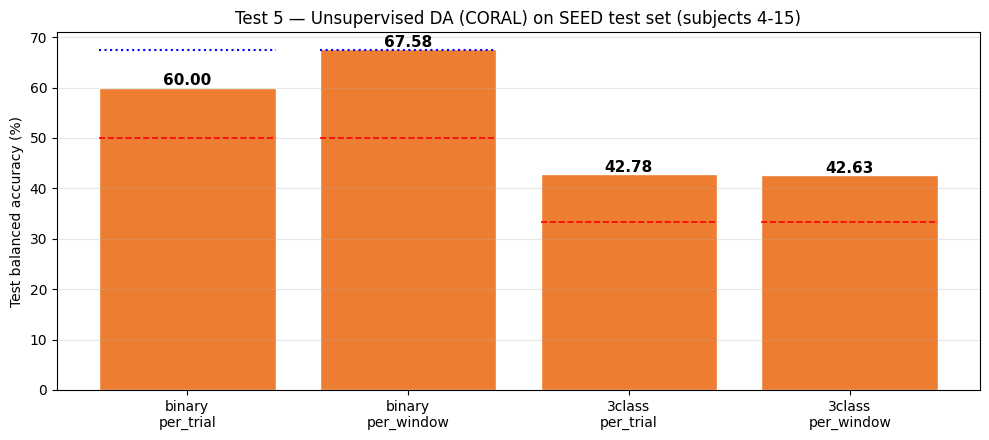

In [14]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 10})
PLOTS_DIR = RESULTS_DIR / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Simple bar chart of Test 5 results
fig, ax = plt.subplots(figsize=(10, 4.5))
labels = [f'{m}\n{p}' for m, p in ALL_RESULTS.keys()]
vals = [100 * r['test_bal'] for r in ALL_RESULTS.values()]
chances = [50.0 if 'binary' in m else 33.3 for (m, p) in ALL_RESULTS.keys()]

x = np.arange(len(labels))
bars = ax.bar(x, vals, color='#ED7D31', edgecolor='white')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.2f}',
            ha='center', fontsize=11, fontweight='bold')
for i, ch in enumerate(chances):
    ax.hlines(ch, x[i]-0.4, x[i]+0.4, colors='red', linestyles='dashed', linewidth=1.2)

# Reference line for Imtiaz & Khan on binary bars
for i, (m, p) in enumerate(ALL_RESULTS.keys()):
    if m == 'binary':
        ax.hlines(67.44, x[i]-0.4, x[i]+0.4, colors='blue', linestyles=':', linewidth=1.5)

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Test balanced accuracy (%)')
ax.set_title('Test 5 — Unsupervised DA (CORAL) on SEED test set (subjects 4-15)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'test5_coral_results.png', dpi=140, bbox_inches='tight')
plt.show()

## 12. Interpretation

**Test 5 uses SEED features during training (CORAL alignment). It is NOT zero-shot.**

**Comparison:**
- **Test 4** = SEED-validation number (baseline)
- **Test 5 CORAL** = unsupervised DA (uses SEED features)
- **Imtiaz & Khan 2024 = 67.44%** — comparable methodology

**Expected:**
- Test 5 binary should exceed Test 4 binary by +5 to +10 pp
- Test 5 target: 65-70% binary (approaching Imtiaz & Khan)
- If Test 5 << 67%, our CORAL implementation may need λ tuning

**Report to Prof. Vu:**
- Test 4 = "zero-shot as intended by brief" honest baseline
- Test 5 = "for comparison to published SOTA, we also ran unsupervised DA"
- Both numbers side by side — full picture, no hiding.

**NEXT if Test 5 helps:**
- Test 6: MMD alignment on SEED (like DANN) instead of CORAL
- Test 7: PC-TTA test-time augmentation (Imtiaz & Khan's other technique)